# Student Pass/Fail Prediction

This project uses student performance data to predict whether a student will pass or fail a mathematics course.

The main goal is not only to build a classification model, but also to compare different models, evaluate them against a baseline, tune model parameters, and improve decision-making using threshold tuning.

In [1]:
import pandas as pd

In [2]:
import os

os.listdir("data")

['Maths.xlsx']

In [3]:
df = pd.read_excel("data/Maths.xlsx")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## Dataset

The dataset contains student information from secondary education. It includes demographic, social, school-related, and academic features.

The target variable is created from the final grade `G3`.

- If `G3 >= 10`, the student is labeled as `Passed = 1`.
- If `G3 < 10`, the student is labeled as `Passed = 0`.

In [4]:
df = pd.read_excel("data/Maths.xlsx")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df.shape

(397, 33)

In [6]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      397 non-null    object
 1   sex         397 non-null    object
 2   age         397 non-null    int64 
 3   address     397 non-null    object
 4   famsize     397 non-null    object
 5   Pstatus     397 non-null    object
 6   Medu        397 non-null    int64 
 7   Fedu        397 non-null    int64 
 8   Mjob        397 non-null    object
 9   Fjob        397 non-null    object
 10  reason      397 non-null    object
 11  guardian    397 non-null    object
 12  traveltime  397 non-null    int64 
 13  studytime   397 non-null    int64 
 14  failures    397 non-null    int64 
 15  schoolsup   397 non-null    object
 16  famsup      397 non-null    object
 17  paid        397 non-null    object
 18  activities  397 non-null    object
 19  nursery     397 non-null    object
 20  higher    

In [8]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

## Target Variable

The original dataset does not contain a direct pass/fail column.

A new target variable named `Passed` was created using the final grade `G3`.

- `Passed = 1` means the student passed.
- `Passed = 0` means the student failed.

In [9]:
df["Passed"] = df["G3"].apply(lambda grade: 1 if grade >= 10 else 0)

df[["G1", "G2", "G3", "Passed"]].head(10)

,G1,G2,G3,Passed
0,5,6,6,0
1,5,5,6,0
2,7,8,10,1
3,15,14,15,1
4,6,10,10,1
5,15,15,15,1
6,12,12,11,1
7,6,5,6,0
8,16,18,19,1
9,14,15,15,1


In [10]:
df["Passed"].value_counts()

Passed
1    265
0    132
Name: count, dtype: int64

In [11]:
df["Passed"].value_counts(normalize=True) * 100

Passed
1    66.75063
0    33.24937
Name: proportion, dtype: float64

## Feature Selection: With Previous Grades

First, the model was trained using `G1` and `G2`, which represent the first and second period grades.

This scenario usually gives stronger predictions because previous grades are closely related to the final grade.

In [12]:
# Model 1: G1 and G2 included

features_with_grades = [
    "school", "sex", "age", "address", "famsize", "Pstatus",
    "Medu", "Fedu", "Mjob", "Fjob", "reason", "guardian",
    "traveltime", "studytime", "failures", "schoolsup", "famsup",
    "paid", "activities", "nursery", "higher", "internet",
    "romantic", "famrel", "freetime", "goout", "Dalc", "Walc",
    "health", "absences", "G1", "G2"
]

X = df[features_with_grades]
y = df["Passed"]

X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,6,5,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,4,5,5
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,10,7,8
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,2,15,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,4,6,10


In [13]:
X.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
dtype: object

## Encoding Categorical Variables

Machine learning models cannot directly understand text-based categorical values such as `yes`, `no`, `GP`, or `MS`.

Therefore, categorical columns were converted into numeric columns using one-hot encoding with `pd.get_dummies()`.

In [14]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_encoded.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


In [15]:
X_encoded.shape

(397, 41)

In [16]:
X_encoded.dtypes.value_counts()

bool     26
int64    15
Name: count, dtype: int64

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((317, 41), (80, 41), (317,), (80,))

## Baseline Machine Learning Model: Decision Tree

A Decision Tree model was used as the first machine learning model.

This model creates decision rules based on the input features and predicts whether a student will pass or fail.

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model_1 = DecisionTreeClassifier(random_state=42)

model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

accuracy_1 = accuracy_score(y_test, y_pred_1)

accuracy_1

0.875

In [19]:
confusion_matrix(y_test, y_pred_1)

array([[26,  1],
       [ 9, 44]])

In [20]:
print(classification_report(y_test, y_pred_1))

              precision    recall  f1-score   support

           0       0.74      0.96      0.84        27
           1       0.98      0.83      0.90        53

    accuracy                           0.88        80
   macro avg       0.86      0.90      0.87        80
weighted avg       0.90      0.88      0.88        80



## Early Prediction Scenario: Without G1 and G2

In this scenario, `G1` and `G2` were removed from the feature set.

This makes the prediction task harder, but more useful for early risk detection because the model does not rely on previous period grades.

In [21]:
# Model 2: G1 and G2 excluded

features_without_grades = [
    "school", "sex", "age", "address", "famsize", "Pstatus",
    "Medu", "Fedu", "Mjob", "Fjob", "reason", "guardian",
    "traveltime", "studytime", "failures", "schoolsup", "famsup",
    "paid", "activities", "nursery", "higher", "internet",
    "romantic", "famrel", "freetime", "goout", "Dalc", "Walc",
    "health", "absences"
]

X2 = df[features_without_grades]
y2 = df["Passed"]

X2_encoded = pd.get_dummies(X2, drop_first=True)

X2_encoded.shape

(397, 39)

## Train-Test Split

The dataset was split into training and testing sets.

- Training data is used to teach the model.
- Testing data is used to evaluate how well the model performs on unseen data.

A stratified split was used to keep the pass/fail ratio similar in both sets.

In [22]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_encoded,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

X2_train.shape, X2_test.shape, y2_train.shape, y2_test.shape

((317, 39), (80, 39), (317,), (80,))

In [23]:
model_2 = DecisionTreeClassifier(random_state=42)

model_2.fit(X2_train, y2_train)

y_pred_2 = model_2.predict(X2_test)

accuracy_2 = accuracy_score(y2_test, y_pred_2)

accuracy_2

0.5875

In [24]:
confusion_matrix(y2_test, y_pred_2)

array([[ 9, 18],
       [15, 38]])

In [25]:
print(classification_report(y2_test, y_pred_2))

              precision    recall  f1-score   support

           0       0.38      0.33      0.35        27
           1       0.68      0.72      0.70        53

    accuracy                           0.59        80
   macro avg       0.53      0.53      0.53        80
weighted avg       0.58      0.59      0.58        80



## Random Forest Model

Random Forest was tested as a stronger tree-based model.

Instead of relying on a single decision tree, Random Forest combines many trees and makes predictions by majority voting.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_model_1 = RandomForestClassifier(random_state=42)

rf_model_1.fit(X_train, y_train)

rf_pred_1 = rf_model_1.predict(X_test)

rf_accuracy_1 = accuracy_score(y_test, rf_pred_1)

rf_accuracy_1

0.8625

In [27]:
confusion_matrix(y_test, rf_pred_1)

array([[24,  3],
       [ 8, 45]])

In [28]:
print(classification_report(y_test, rf_pred_1))

              precision    recall  f1-score   support

           0       0.75      0.89      0.81        27
           1       0.94      0.85      0.89        53

    accuracy                           0.86        80
   macro avg       0.84      0.87      0.85        80
weighted avg       0.87      0.86      0.86        80



In [29]:
rf_model_2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model_2.fit(X2_train, y2_train)

rf_pred_2 = rf_model_2.predict(X2_test)

rf_accuracy_2 = accuracy_score(y2_test, rf_pred_2)

rf_accuracy_2

0.6625

In [30]:
confusion_matrix(y2_test, rf_pred_2)

array([[ 6, 21],
       [ 6, 47]])

In [31]:
print(classification_report(y2_test, rf_pred_2))

              precision    recall  f1-score   support

           0       0.50      0.22      0.31        27
           1       0.69      0.89      0.78        53

    accuracy                           0.66        80
   macro avg       0.60      0.55      0.54        80
weighted avg       0.63      0.66      0.62        80



In [32]:
model_results = pd.DataFrame({
    "Model": [
        "Decision Tree with G1/G2",
        "Decision Tree without G1/G2",
        "Random Forest with G1/G2",
        "Random Forest without G1/G2"
    ],
    "Accuracy": [
        accuracy_1,
        accuracy_2,
        rf_accuracy_1,
        rf_accuracy_2
    ]
})

model_results

,Model,Accuracy
0,Decision Tree with G1/G2,0.8750
1,Decision Tree without G1/G2,0.5875
2,Random Forest with G1/G2,0.8625
3,Random Forest without G1/G2,0.6625


In [33]:
feature_importance_1 = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model_1.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_1.head(10)

,Feature,Importance
14,G2,0.351110
13,G1,0.217912
5,failures,0.042659
12,absences,0.040893
8,goout,0.024203
0,age,0.022652
10,Walc,0.020099
7,freetime,0.016796
11,health,0.016502
2,Fedu,0.016025


In [34]:
feature_importance_2 = pd.DataFrame({
    "Feature": X2_encoded.columns,
    "Importance": rf_model_2.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance_2.head(10)

,Feature,Importance
5,failures,0.090745
12,absences,0.087086
8,goout,0.060675
0,age,0.060217
11,health,0.043319
7,freetime,0.041343
2,Fedu,0.040653
10,Walc,0.040182
6,famrel,0.038011
1,Medu,0.036073


## Majority Class Baseline

Before evaluating improved models, a simple baseline was calculated.

This baseline always predicts the majority class. Since most students passed, the baseline predicts every student as passed.

This gives a reference point. A machine learning model should perform better than this baseline to be considered useful.

In [35]:
baseline_accuracy = y2_test.value_counts(normalize=True).max()
baseline_accuracy

0.6625

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

log_model_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

log_model_2.fit(X2_train, y2_train)

log_pred_2 = log_model_2.predict(X2_test)

log_accuracy_2 = accuracy_score(y2_test, log_pred_2)

log_accuracy_2

0.65

In [37]:
confusion_matrix(y2_test, log_pred_2)

array([[ 9, 18],
       [10, 43]])

In [38]:
print(classification_report(y2_test, log_pred_2))

              precision    recall  f1-score   support

           0       0.47      0.33      0.39        27
           1       0.70      0.81      0.75        53

    accuracy                           0.65        80
   macro avg       0.59      0.57      0.57        80
weighted avg       0.63      0.65      0.63        80



## Model Tuning

The initial Random Forest model performed close to the baseline in the early prediction scenario.

To improve performance, hyperparameters were adjusted manually. The goal was to reduce overfitting, handle class imbalance, and improve the detection of failing students.

In [39]:
rf_tuned_2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf_tuned_2.fit(X2_train, y2_train)

rf_tuned_pred_2 = rf_tuned_2.predict(X2_test)

rf_tuned_accuracy_2 = accuracy_score(y2_test, rf_tuned_pred_2)

rf_tuned_accuracy_2

0.725

In [40]:
confusion_matrix(y2_test, rf_tuned_pred_2)

array([[14, 13],
       [ 9, 44]])

In [41]:
print(classification_report(y2_test, rf_tuned_pred_2))

              precision    recall  f1-score   support

           0       0.61      0.52      0.56        27
           1       0.77      0.83      0.80        53

    accuracy                           0.72        80
   macro avg       0.69      0.67      0.68        80
weighted avg       0.72      0.72      0.72        80



In [42]:
improved_results = pd.DataFrame({
    "Model": [
        "Baseline Majority Class",
        "Decision Tree without G1/G2",
        "Random Forest without G1/G2",
        "Logistic Regression without G1/G2",
        "Tuned Random Forest without G1/G2"
    ],
    "Accuracy": [
        baseline_accuracy,
        accuracy_2,
        rf_accuracy_2,
        log_accuracy_2,
        rf_tuned_accuracy_2
    ]
})

improved_results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
4,Tuned Random Forest without G1/G2,0.7250
0,Baseline Majority Class,0.6625
2,Random Forest without G1/G2,0.6625
3,Logistic Regression without G1/G2,0.6500
1,Decision Tree without G1/G2,0.5875


In [43]:
tuned_feature_importance = pd.DataFrame({
    "Feature": X2_encoded.columns,
    "Importance": rf_tuned_2.feature_importances_
}).sort_values(by="Importance", ascending=False)

tuned_feature_importance.head(10)

,Feature,Importance
5,failures,0.166880
12,absences,0.105333
8,goout,0.082465
0,age,0.053948
11,health,0.039460
2,Fedu,0.038797
10,Walc,0.037195
1,Medu,0.032286
31,schoolsup_yes,0.031551
14,sex_M,0.030783


## Cross-Validation

A single train-test split can sometimes give a lucky or unlucky result.

Cross-validation was used to evaluate the model across multiple data splits and get a more reliable estimate of performance.

In [44]:
from sklearn.model_selection import cross_val_score

cv_scores_rf_tuned = cross_val_score(
    rf_tuned_2,
    X2_encoded,
    y2,
    cv=5,
    scoring="accuracy"
)

cv_scores_rf_tuned, cv_scores_rf_tuned.mean(), cv_scores_rf_tuned.std()

(array([0.675     , 0.725     , 0.67088608, 0.62025316, 0.65822785]),
 np.float64(0.669873417721519),
 np.float64(0.0336572019399875))

In [45]:
from sklearn.metrics import make_scorer, recall_score, f1_score

cv_recall_fail = cross_val_score(
    rf_tuned_2,
    X2_encoded,
    y2,
    cv=5,
    scoring=make_scorer(recall_score, pos_label=0)
)

cv_f1_fail = cross_val_score(
    rf_tuned_2,
    X2_encoded,
    y2,
    cv=5,
    scoring=make_scorer(f1_score, pos_label=0)
)

cv_recall_fail.mean(), cv_f1_fail.mean()

(np.float64(0.4404558404558404), np.float64(0.4503052503052503))

## Hyperparameter Optimization with GridSearchCV

GridSearchCV was used to systematically test different Random Forest hyperparameter combinations.

The goal was to find a more balanced model using cross-validation instead of manually guessing parameter values.

In [46]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 3, 5, 10],
    "class_weight": [None, "balanced"]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_rf.fit(X2_train, y2_train)

grid_rf.best_params_, grid_rf.best_score_

({'class_weight': 'balanced',
  'max_depth': 5,
  'min_samples_leaf': 3,
  'min_samples_split': 2,
  'n_estimators': 100},
 np.float64(0.6816305796094926))

In [47]:
best_rf = grid_rf.best_estimator_

best_rf_pred = best_rf.predict(X2_test)

best_rf_accuracy = accuracy_score(y2_test, best_rf_pred)

best_rf_accuracy

0.7375

In [48]:
confusion_matrix(y2_test, best_rf_pred)

array([[14, 13],
       [ 8, 45]])

In [49]:
print(classification_report(y2_test, best_rf_pred))

              precision    recall  f1-score   support

           0       0.64      0.52      0.57        27
           1       0.78      0.85      0.81        53

    accuracy                           0.74        80
   macro avg       0.71      0.68      0.69        80
weighted avg       0.73      0.74      0.73        80



## Feature Engineering

New features were created by combining existing variables.

The goal was to test whether engineered features such as parental education, alcohol consumption, social activity, and risk history could improve model performance.

In [50]:
df_fe = df.copy()

df_fe["parent_education"] = df_fe["Medu"] + df_fe["Fedu"]
df_fe["alcohol_total"] = df_fe["Dalc"] + df_fe["Walc"]
df_fe["social_activity"] = df_fe["goout"] + df_fe["freetime"]
df_fe["risk_history"] = df_fe["failures"] * 3 + df_fe["absences"] * 0.2
df_fe["study_absence_balance"] = df_fe["studytime"] - (df_fe["absences"] / 10)

In [51]:
features_fe = features_without_grades + [
    "parent_education",
    "alcohol_total",
    "social_activity",
    "risk_history",
    "study_absence_balance"
]

X_fe = df_fe[features_fe]
y_fe = df_fe["Passed"]

X_fe_encoded = pd.get_dummies(X_fe, drop_first=True)

X_fe_train, X_fe_test, y_fe_train, y_fe_test = train_test_split(
    X_fe_encoded,
    y_fe,
    test_size=0.2,
    random_state=42,
    stratify=y_fe
)

In [52]:
best_rf.predict_proba(X2_test)

array([[0.39445184, 0.60554816],
       [0.56389181, 0.43610819],
       [0.47561113, 0.52438887],
       [0.5180386 , 0.4819614 ],
       [0.40618488, 0.59381512],
       [0.49522732, 0.50477268],
       [0.31985979, 0.68014021],
       [0.32585711, 0.67414289],
       [0.48642896, 0.51357104],
       [0.41321292, 0.58678708],
       [0.63749042, 0.36250958],
       [0.45496672, 0.54503328],
       [0.35409966, 0.64590034],
       [0.37491859, 0.62508141],
       [0.40451438, 0.59548562],
       [0.33920261, 0.66079739],
       [0.66792198, 0.33207802],
       [0.32660934, 0.67339066],
       [0.65183342, 0.34816658],
       [0.43363708, 0.56636292],
       [0.35001352, 0.64998648],
       [0.35591698, 0.64408302],
       [0.62199048, 0.37800952],
       [0.59195584, 0.40804416],
       [0.41098251, 0.58901749],
       [0.37764847, 0.62235153],
       [0.46830854, 0.53169146],
       [0.32839837, 0.67160163],
       [0.50640157, 0.49359843],
       [0.35355794, 0.64644206],
       [0.

In [53]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 3, 5, 10],
    "class_weight": [None, "balanced"]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid_rf.fit(X2_train, y2_train)

grid_rf.best_params_, grid_rf.best_score_

({'class_weight': 'balanced',
  'max_depth': 5,
  'min_samples_leaf': 3,
  'min_samples_split': 2,
  'n_estimators': 100},
 np.float64(0.6816305796094926))

In [54]:
fe_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=3,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42
)

fe_rf.fit(X_fe_train, y_fe_train)

fe_rf_pred = fe_rf.predict(X_fe_test)

fe_rf_accuracy = accuracy_score(y_fe_test, fe_rf_pred)

fe_rf_accuracy

0.6625

In [55]:
confusion_matrix(y_fe_test, fe_rf_pred)

array([[12, 15],
       [12, 41]])

In [56]:
print(classification_report(y_fe_test, fe_rf_pred))

              precision    recall  f1-score   support

           0       0.50      0.44      0.47        27
           1       0.73      0.77      0.75        53

    accuracy                           0.66        80
   macro avg       0.62      0.61      0.61        80
weighted avg       0.65      0.66      0.66        80



In [57]:
fe_cv_accuracy = cross_val_score(
    fe_rf,
    X_fe_encoded,
    y_fe,
    cv=5,
    scoring="accuracy"
)

fe_cv_f1_macro = cross_val_score(
    fe_rf,
    X_fe_encoded,
    y_fe,
    cv=5,
    scoring="f1_macro"
)

fe_cv_fail_recall = cross_val_score(
    fe_rf,
    X_fe_encoded,
    y_fe,
    cv=5,
    scoring=make_scorer(recall_score, pos_label=0)
)

fe_cv_accuracy.mean(), fe_cv_f1_macro.mean(), fe_cv_fail_recall.mean()

(np.float64(0.6927215189873419),
 np.float64(0.6266850422866109),
 np.float64(0.4401709401709401))

In [58]:
final_comparison = pd.DataFrame({
    "Model": [
        "Baseline Majority Class",
        "Decision Tree without G1/G2",
        "Random Forest without G1/G2",
        "Logistic Regression without G1/G2",
        "Tuned Random Forest without G1/G2",
        "GridSearch Random Forest without G1/G2",
        "Feature Engineered Random Forest without G1/G2"
    ],
    "Test Accuracy": [
        baseline_accuracy,
        accuracy_2,
        rf_accuracy_2,
        log_accuracy_2,
        rf_tuned_accuracy_2,
        best_rf_accuracy,
        fe_rf_accuracy
    ]
})

final_comparison.sort_values(by="Test Accuracy", ascending=False)

,Model,Test Accuracy
5,GridSearch Random Forest without G1/G2,0.7375
4,Tuned Random Forest without G1/G2,0.7250
0,Baseline Majority Class,0.6625
6,Feature Engineered Random Forest without G1/G2,0.6625
2,Random Forest without G1/G2,0.6625
3,Logistic Regression without G1/G2,0.6500
1,Decision Tree without G1/G2,0.5875


In [59]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

pass_prob = best_rf.predict_proba(X2_test)[:, 1]

threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):
    pred_threshold = (pass_prob >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y2_test, pred_threshold),
        "Fail Recall": recall_score(y2_test, pred_threshold, pos_label=0),
        "Fail F1": f1_score(y2_test, pred_threshold, pos_label=0),
        "Pass Recall": recall_score(y2_test, pred_threshold, pos_label=1)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df

,Threshold,Accuracy,Fail Recall,Fail F1,Pass Recall
0,0.30,0.6750,0.037037,0.071429,1.000000
1,0.35,0.6750,0.074074,0.133333,0.981132
2,0.40,0.6875,0.185185,0.285714,0.943396
3,0.45,0.6750,0.296296,0.380952,0.867925
4,0.50,0.7375,0.518519,0.571429,0.849057
5,0.55,0.6875,0.592593,0.561404,0.735849
6,0.60,0.6375,0.740741,0.579710,0.584906
7,0.65,0.4625,0.925926,0.537634,0.226415
8,0.70,0.4000,1.000000,0.529412,0.094340


In [60]:
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import GridSearchCV

param_grid_balanced = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 3, 5, 10],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

grid_rf_balanced = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_balanced,
    cv=5,
    scoring="balanced_accuracy",
    n_jobs=-1
)

grid_rf_balanced.fit(X2_train, y2_train)

grid_rf_balanced.best_params_, grid_rf_balanced.best_score_

({'class_weight': 'balanced',
  'max_depth': 5,
  'min_samples_leaf': 5,
  'min_samples_split': 20,
  'n_estimators': 100},
 np.float64(0.67984496124031))

In [61]:
best_rf_balanced = grid_rf_balanced.best_estimator_

balanced_pred = best_rf_balanced.predict(X2_test)

balanced_accuracy = accuracy_score(y2_test, balanced_pred)
balanced_accuracy_metric = balanced_accuracy_score(y2_test, balanced_pred)

balanced_accuracy, balanced_accuracy_metric

(0.6875, np.float64(0.6369671558350803))

In [62]:
confusion_matrix(y2_test, balanced_pred)

array([[13, 14],
       [11, 42]])

In [63]:
print(classification_report(y2_test, balanced_pred))

              precision    recall  f1-score   support

           0       0.54      0.48      0.51        27
           1       0.75      0.79      0.77        53

    accuracy                           0.69        80
   macro avg       0.65      0.64      0.64        80
weighted avg       0.68      0.69      0.68        80



## Additional Model Experiments

Additional models were tested to check whether other algorithms could outperform the tuned Random Forest model.

The tested models included Extra Trees and Gradient Boosting.

In [64]:
from sklearn.ensemble import ExtraTreesClassifier

extra_model = ExtraTreesClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=42
)

extra_model.fit(X2_train, y2_train)

extra_pred = extra_model.predict(X2_test)

extra_accuracy = accuracy_score(y2_test, extra_pred)
extra_balanced_accuracy = balanced_accuracy_score(y2_test, extra_pred)

extra_accuracy, extra_balanced_accuracy

(0.7, np.float64(0.6464011180992313))

In [65]:
confusion_matrix(y2_test, extra_pred)

array([[13, 14],
       [10, 43]])

In [66]:
print(classification_report(y2_test, extra_pred))

              precision    recall  f1-score   support

           0       0.57      0.48      0.52        27
           1       0.75      0.81      0.78        53

    accuracy                           0.70        80
   macro avg       0.66      0.65      0.65        80
weighted avg       0.69      0.70      0.69        80



In [67]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X2_train, y2_train)

gb_pred = gb_model.predict(X2_test)

gb_accuracy = accuracy_score(y2_test, gb_pred)
gb_balanced_accuracy = balanced_accuracy_score(y2_test, gb_pred)

gb_accuracy, gb_balanced_accuracy

(0.65, np.float64(0.5723270440251572))

In [68]:
confusion_matrix(y2_test, gb_pred)

array([[ 9, 18],
       [10, 43]])

In [69]:
print(classification_report(y2_test, gb_pred))

              precision    recall  f1-score   support

           0       0.47      0.33      0.39        27
           1       0.70      0.81      0.75        53

    accuracy                           0.65        80
   macro avg       0.59      0.57      0.57        80
weighted avg       0.63      0.65      0.63        80



## Threshold Tuning

The model normally uses a default threshold of 0.50 to convert pass probabilities into pass/fail predictions.

Different thresholds were tested to find a better balance between overall accuracy and failing-student detection.

In [70]:
threshold_results_fine = []

for threshold in np.arange(0.40, 0.66, 0.01):
    pred_threshold = (pass_prob >= threshold).astype(int)
    
    threshold_results_fine.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y2_test, pred_threshold),
        "Balanced Accuracy": balanced_accuracy_score(y2_test, pred_threshold),
        "Fail Precision": precision_score(y2_test, pred_threshold, pos_label=0),
        "Fail Recall": recall_score(y2_test, pred_threshold, pos_label=0),
        "Fail F1": f1_score(y2_test, pred_threshold, pos_label=0),
        "Pass Recall": recall_score(y2_test, pred_threshold, pos_label=1)
    })

threshold_results_fine_df = pd.DataFrame(threshold_results_fine)

threshold_results_fine_df.sort_values(by="Fail F1", ascending=False).head(10)

,Threshold,Accuracy,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1,Pass Recall
12,0.52,0.7375,0.692872,0.625000,0.555556,0.588235,0.830189
14,0.54,0.7125,0.683089,0.571429,0.592593,0.581818,0.773585
20,0.60,0.6375,0.662823,0.476190,0.740741,0.579710,0.584906
23,0.63,0.5625,0.642558,0.428571,0.888889,0.578313,0.396226
19,0.59,0.6500,0.663173,0.487179,0.703704,0.575758,0.622642
10,0.50,0.7375,0.683788,0.636364,0.518519,0.571429,0.849057
13,0.53,0.7125,0.674004,0.576923,0.555556,0.566038,0.792453
18,0.58,0.6500,0.654088,0.486486,0.666667,0.562500,0.641509
15,0.55,0.6875,0.664221,0.533333,0.592593,0.561404,0.735849
11,0.51,0.7250,0.674354,0.608696,0.518519,0.560000,0.830189


In [71]:
threshold_results_fine_df.sort_values(by="Balanced Accuracy", ascending=False).head(10)

,Threshold,Accuracy,Balanced Accuracy,Fail Precision,Fail Recall,Fail F1,Pass Recall
12,0.52,0.7375,0.692872,0.625000,0.555556,0.588235,0.830189
10,0.50,0.7375,0.683788,0.636364,0.518519,0.571429,0.849057
14,0.54,0.7125,0.683089,0.571429,0.592593,0.581818,0.773585
11,0.51,0.7250,0.674354,0.608696,0.518519,0.560000,0.830189
13,0.53,0.7125,0.674004,0.576923,0.555556,0.566038,0.792453
15,0.55,0.6875,0.664221,0.533333,0.592593,0.561404,0.735849
19,0.59,0.6500,0.663173,0.487179,0.703704,0.575758,0.622642
20,0.60,0.6375,0.662823,0.476190,0.740741,0.579710,0.584906
16,0.56,0.6750,0.654787,0.516129,0.592593,0.551724,0.716981
18,0.58,0.6500,0.654088,0.486486,0.666667,0.562500,0.641509


## Final Model Selection

The final model was selected based on accuracy, balanced accuracy, confusion matrix results, and failing-student recall.

The selected model is the GridSearch Random Forest model with a threshold of 0.52.

This threshold kept the same accuracy as the default 0.50 threshold while improving balanced accuracy.

In [72]:
final_threshold = 0.52

final_pass_prob = best_rf.predict_proba(X2_test)[:, 1]
final_pred = (final_pass_prob >= final_threshold).astype(int)

final_accuracy = accuracy_score(y2_test, final_pred)
final_balanced_accuracy = balanced_accuracy_score(y2_test, final_pred)

final_accuracy, final_balanced_accuracy

(0.7375, np.float64(0.6928721174004193))

In [73]:
confusion_matrix(y2_test, final_pred)

array([[15, 12],
       [ 9, 44]])

In [74]:
print(classification_report(y2_test, final_pred))

              precision    recall  f1-score   support

           0       0.62      0.56      0.59        27
           1       0.79      0.83      0.81        53

    accuracy                           0.74        80
   macro avg       0.71      0.69      0.70        80
weighted avg       0.73      0.74      0.73        80



In [75]:
risk_row = threshold_results_fine_df.iloc[
    (threshold_results_fine_df["Threshold"] - 0.60).abs().argsort()[:1]
]

risk_accuracy = risk_row["Accuracy"].values[0]
risk_balanced_accuracy = risk_row["Balanced Accuracy"].values[0]

final_model_summary = pd.DataFrame({
    "Model": [
        "Baseline Majority Class",
        "Best Random Forest - threshold 0.50",
        "Final Random Forest - threshold 0.52",
        "Risk-focused Random Forest - threshold 0.60"
    ],
    "Accuracy": [
        baseline_accuracy,
        best_rf_accuracy,
        final_accuracy,
        risk_accuracy
    ],
    "Balanced Accuracy": [
        baseline_accuracy,
        balanced_accuracy_score(y2_test, best_rf_pred),
        final_balanced_accuracy,
        risk_balanced_accuracy
    ]
})

final_model_summary

,Model,Accuracy,Balanced Accuracy
0,Baseline Majority Class,0.6625,0.662500
1,Best Random Forest - threshold 0.50,0.7375,0.683788
2,Final Random Forest - threshold 0.52,0.7375,0.692872
3,Risk-focused Random Forest - threshold 0.60,0.6375,0.662823


## Visualizations

The following visualizations summarize the model comparison, threshold tuning results, and the most important features used by the final model.

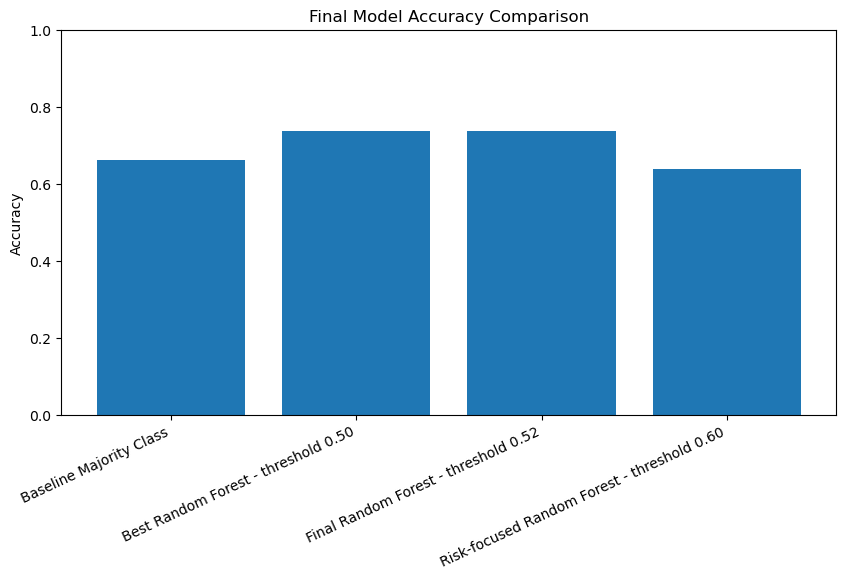

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(final_model_summary["Model"], final_model_summary["Accuracy"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Accuracy")
plt.title("Final Model Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

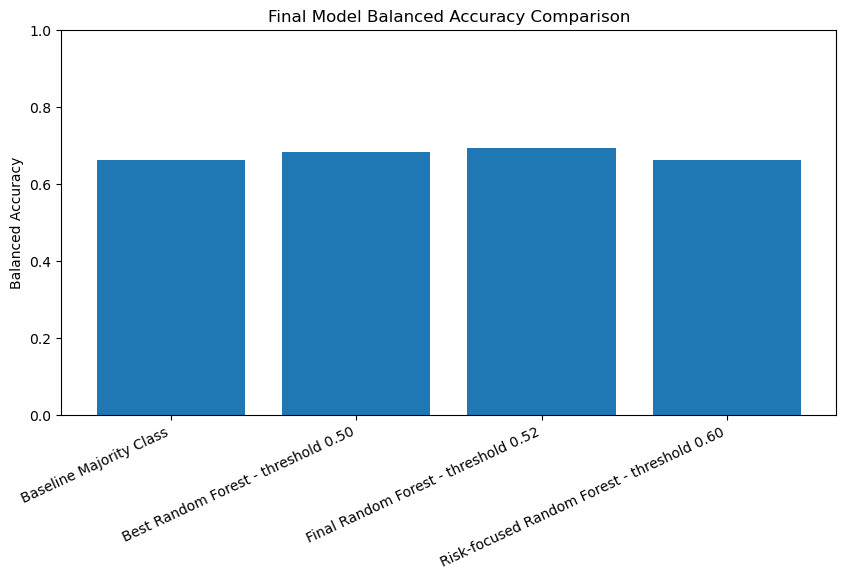

In [77]:
plt.figure(figsize=(10, 5))
plt.bar(final_model_summary["Model"], final_model_summary["Balanced Accuracy"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("Balanced Accuracy")
plt.title("Final Model Balanced Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

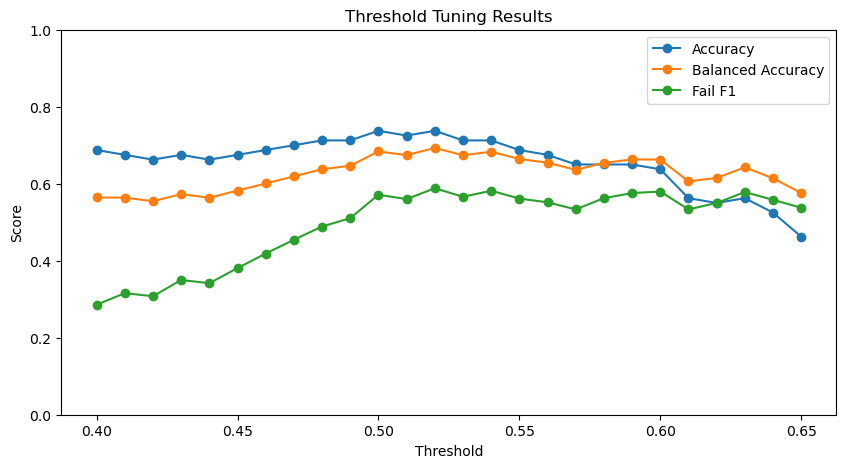

In [78]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_results_fine_df["Threshold"], threshold_results_fine_df["Accuracy"], marker="o", label="Accuracy")
plt.plot(threshold_results_fine_df["Threshold"], threshold_results_fine_df["Balanced Accuracy"], marker="o", label="Balanced Accuracy")
plt.plot(threshold_results_fine_df["Threshold"], threshold_results_fine_df["Fail F1"], marker="o", label="Fail F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning Results")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [79]:
final_feature_importance = pd.DataFrame({
    "Feature": X2_encoded.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

final_feature_importance.head(10)

,Feature,Importance
5,failures,0.169752
12,absences,0.089951
8,goout,0.077039
0,age,0.049176
11,health,0.039622
10,Walc,0.038643
9,Dalc,0.038382
2,Fedu,0.037968
31,schoolsup_yes,0.035039
7,freetime,0.032325


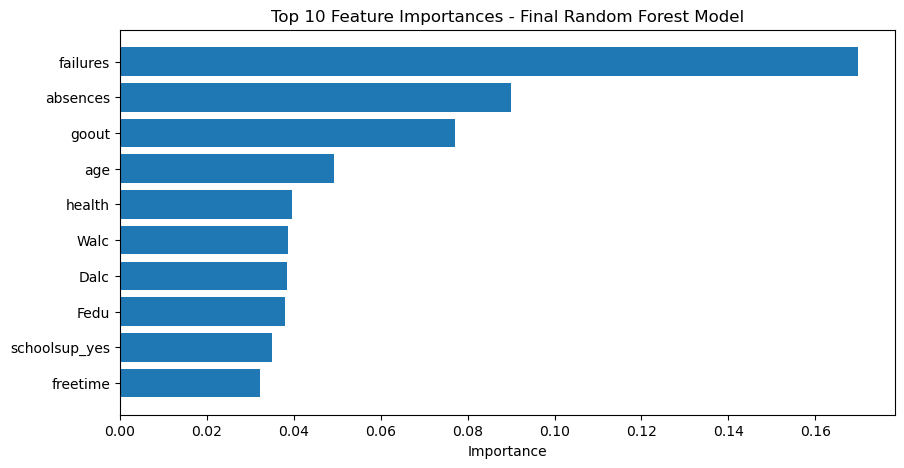

In [80]:
top_final_features = final_feature_importance.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_final_features["Feature"], top_final_features["Importance"])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances - Final Random Forest Model")
plt.gca().invert_yaxis()
plt.show()

## Conclusion

The final selected model was a GridSearch Random Forest model without using `G1` and `G2`.

The final threshold was set to `0.52`.

Final model performance:

- Accuracy: 73.75%
- Balanced Accuracy: 69.29%
- Correctly identified 15 out of 27 failing students
- Correctly identified 44 out of 53 passing students

The project showed that previous grades are very strong predictors of final performance. However, when previous grades are removed, early pass/fail prediction becomes more difficult and requires careful model tuning and threshold optimization.

## Limitations and Future Improvements

Limitations:

- The dataset is relatively small.
- The model does not include all real-life factors affecting student performance.
- Some features may be self-reported and may not fully represent real student behavior.
- Results may change with different train-test splits.

Future improvements:

- Test the model on the Portuguese course dataset.
- Compare Math and Portuguese course performance.
- Try more advanced models.
- Use more detailed cross-validation analysis.
- Build a Streamlit app for interactive student risk prediction.